# Machine Learning for CICY 4-folds

Following the analysis in [arXiv:2007.13379](http://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](http://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds. The idea is to see whether the Inception network can also be applied in higher dimensions.

## Exploratory Data Analysis

In this notebook we focus on the exploratory data analysis necessary to better understand the composition of the dataset.
We use a complete [dataset](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz.txt) containing engineered features and the labels (i.e. the Hodge numbers).

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

In [2]:
seaborn_theme = {'context':     'notebook',
                 'style':       'darkgrid',
                 'palette':     'deep',
                 'color_codes': True
                }

sns.set_theme(**seaborn_theme)
sns.set_context('notebook')

to_tex = lambda s: '${base}^{{ {first}, {second} }}$'.format(base=s[0], first=s[1], second=s[2])

In [3]:
os.makedirs('./img', exist_ok=True)

## Read the Dataset

We read the dataset from its [URL](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz) and display basic information.

In [4]:
df = pd.read_json('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz', orient='index')
n_rows, n_cols = df.shape

As we can see, the dataset is large and takes up a lot of RAM.

In [5]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 921497 entries, 1 to 921497
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   euler           921497 non-null  int64  
 1   favour          921497 non-null  bool   
 2   h11             905684 non-null  float64
 3   h21             905684 non-null  float64
 4   h22             905684 non-null  float64
 5   h31             905684 non-null  float64
 6   isprod          921497 non-null  bool   
 7   matrix          921497 non-null  object 
 8   size            921497 non-null  object 
 9   num_cp          921497 non-null  int64  
 10  num_eqs         921497 non-null  int64  
 11  num_cp_1        921497 non-null  int64  
 12  num_cp_2        921497 non-null  int64  
 13  num_cp_neq1     921497 non-null  int64  
 14  num_ex          921497 non-null  int64  
 15  norm_matrix     921497 non-null  float64
 16  rank_matrix     921497 non-null  int64  
 17  dim_cp    

We also notice that there are incomplete cases:

In [6]:
df.isna().sum()

euler                 0
favour                0
h11               15813
h21               15813
h22               15813
h31               15813
isprod                0
matrix                0
size                  0
num_cp                0
num_eqs               0
num_cp_1              0
num_cp_2              0
num_cp_neq1           0
num_ex                0
norm_matrix           0
rank_matrix           0
dim_cp                0
min_dim_cp            0
max_dim_cp            0
mean_dim_cp           0
std_dim_cp            0
median_dim_cp         0
quart_dim_cp          0
deg_eqs               0
min_deg_eqs           0
max_deg_eqs           0
mean_deg_eqs          0
std_deg_eqs           0
median_deg_eqs        0
quart_deg_eqs         0
dtype: int64

They are connected with the configuration matrix being in block diagonal form, i.e. a product space:

In [7]:
df.loc[df['h11'].isna() & df['h21'].isna() & df['h31'].isna() & df['h22'].isna(), 'isprod'].all()

True

While the complete cases are not product spaces:

In [8]:
df.loc[~df['h11'].isna() & ~df['h21'].isna() & ~df['h31'].isna() & ~df['h22'].isna(), 'isprod'].any()

False

We can therefore discard them:

In [9]:
df = df.loc[df['isprod'] == False].drop(columns=['isprod', 'favour'])

## Data Type Conversion

For better representation and handling, we convert a few data types into more sensible dtypes:

In [10]:
df.loc[:, ['h11', 'h21', 'h31', 'h22']] = df[['h11', 'h21', 'h31', 'h22']].astype(np.int)

## Distribution of the Labels

Before moving to the data analysis, we take a look at the distribution of the labels and their classes in order to split the dataset with a stratified approach (notice that $h^{2,1}$ vanishes for almost $70\%$ of the cases).
The idea of the exploratory analysis is, in fact, to highlight properties of the data: we keep one "training" set for the hypotheses, and a "test" set to evaluate it.

In [11]:
df['h11'].value_counts().head(5) / n_rows

10    0.164349
9     0.156746
11    0.144000
8     0.123348
12    0.108164
Name: h11, dtype: float64

In [12]:
df['h21'].value_counts().head(5) / n_rows

0    0.688513
1    0.134249
2    0.049091
3    0.039955
4    0.021612
Name: h21, dtype: float64

In [13]:
df['h31'].value_counts().head(5) / n_rows

32    0.058487
34    0.054021
30    0.053513
31    0.052844
33    0.051783
Name: h31, dtype: float64

In [14]:
df['h22'].value_counts().head(5) / n_rows

204    0.104997
216    0.084256
228    0.069154
208    0.048952
212    0.047016
Name: h22, dtype: float64

We then visualise their intervals of definition:

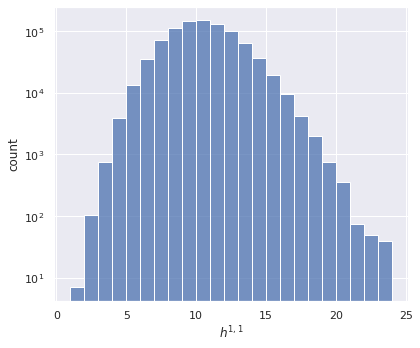

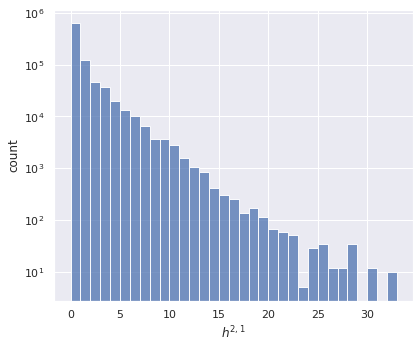

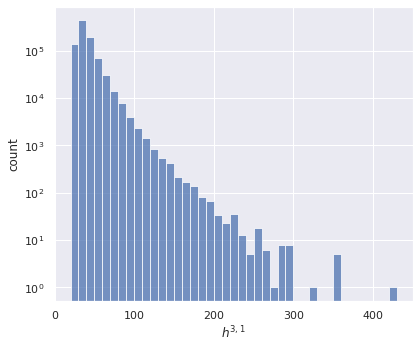

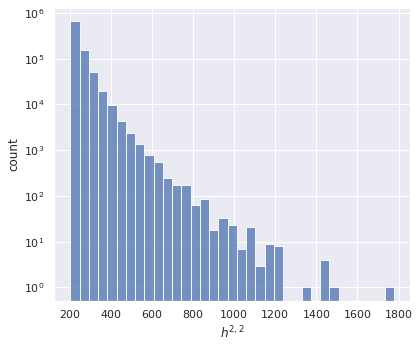

In [15]:
binwidth = {'h11': 1, 'h21': 1, 'h31': 10, 'h22': 45}

for lab, bw in binwidth.items():
    
    fig, ax = plt.subplots(1, 1, figsize=(6,5))
    
    sns.histplot(df.loc[:, lab], binwidth=bw, log_scale=(False, True), ax=ax)
    ax.set(xlabel=to_tex(lab), ylabel='count')
    
    fig.tight_layout()
    fig.savefig(os.path.join('./img', lab + '.pdf'))
    plt.show()
    plt.close(fig)

As we can see the intervals are very diverse among the labels.
Moreover, $h^{2,1}$ should be considered carefully as it vanishes for almost $70\%$ of the cases.
This suggests a stratified approach.

## Train and Test Splits

We then divide the set into a training and a test set to study correlations and covariances.
The division is stratified on $h^{2,1}$ to avoid difficulties with the unbalanced classes.

In [16]:
train = df.groupby(by='h21', group_keys=False).apply(lambda x: x.sample(frac=0.8))
test  = df.loc[~df.index.isin(train.index)]

print(f'Training set: {train.shape[0]:d} rows ({100 * train.shape[0] / n_rows:.1f}% ratio)')
print(f'Test set:     {test.shape[0]:d} rows ({100 * test.shape[0] / n_rows:.1f}% ratio)')

Training set: 724547 rows (78.6% ratio)
Test set:     181137 rows (19.7% ratio)


We then plot the full distribution of $h^{2,1}$ against its training and test folds for comparison:

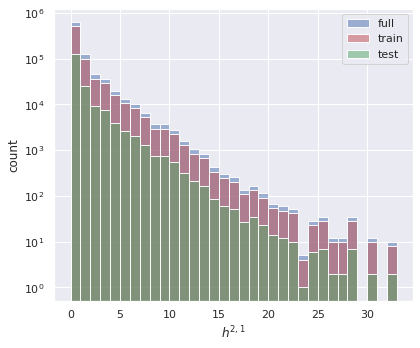

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

sns.histplot(df.loc[:, 'h21'],    binwidth=1, color='b', alpha=0.5, log_scale=(False, True), label='full',  ax=ax)
sns.histplot(train.loc[:, 'h21'], binwidth=1, color='r', alpha=0.5, log_scale=(False, True), label='train', ax=ax)
sns.histplot(test.loc[:, 'h21'],  binwidth=1, color='g', alpha=0.5, log_scale=(False, True), label='test',  ax=ax)

ax.set(xlabel=to_tex('h21'), ylabel='count')
ax.legend()

fig.tight_layout()
fig.savefig('./img/stratified.pdf')
plt.show()
plt.close(fig)

## Correlations and Covariance

We then plot the correlation matrix of features and labels, and their covariance matrix (standardised).

In [18]:
columns = {'features': df.select_dtypes(exclude='object').columns.drop(['h11', 'h21', 'h31', 'h22']).tolist(),
           'labels':   ['h11', 'h21', 'h31', 'h22']
          }

# standardisation
mean_features = train.loc[:, columns['features']].mean()
std_features  = train.loc[:, columns['features']].std()
mean_labels   = train.loc[:, columns['labels']].mean()
std_labels    = train.loc[:, columns['labels']].std()

train_features = (train.loc[:, columns['features']] - mean_features) / std_features
train_labels   = (train.loc[:, columns['labels']] - mean_labels) / std_labels

test_features  = (test.loc[:, columns['features']] - mean_features) / std_features
test_labels    = (test.loc[:, columns['labels']] - mean_labels) / std_labels

# correlation and covariance
corr = {'train_features': train_features.corr(),
        'test_features':  test_features.corr(),
        'train_labels':   train_labels.corr(),
        'test_labels':    test_labels.corr()
       }

cov = {'train_features': train_features.cov(),
       'test_features':  test_features.cov(),
       'train_labels':   train_labels.cov(),
       'test_labels':    test_labels.cov()
      }

We plot the correlation matrices:

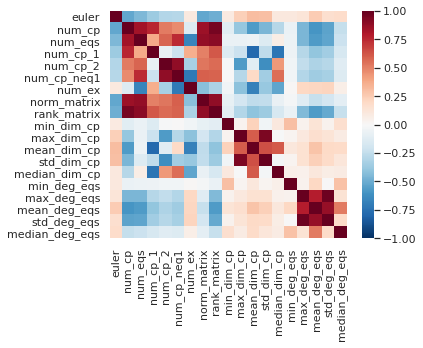

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

sns.heatmap(corr['train_features'], vmin=-1.0, vmax=1.0, cmap='RdBu_r', center=0.0, ax=ax)

fig.tight_layout()
fig.savefig('./img/corr_train_features.pdf')
plt.show()
plt.close(fig)

As we can see there is a good degree of correlation between the different definition of `num_cp`, and the norm and rank of the matrix.
In fact, we could think of using just one of the definitions for predictions (e.g. `num_cp` and `norm_matrix`).

However we want to test this on the test set of the EDA to be sure.
We compute the difference of the correlation matrices and test how close to $0$ they are:

In [20]:
corr_diff = np.abs(corr['train_features'] - corr['test_features'])

print(f'Maximal difference: {corr_diff.max().max():.3f}')

Maximal difference: 0.027


Moreover the maximal differences for each variable correspond to:

In [21]:
corr_diff.idxmax()

euler             median_deg_eqs
num_cp               min_deg_eqs
num_eqs              min_deg_eqs
num_cp_1          median_deg_eqs
num_cp_2             min_deg_eqs
num_cp_neq1          mean_dim_cp
num_ex            median_deg_eqs
norm_matrix          min_deg_eqs
rank_matrix          min_deg_eqs
min_dim_cp           min_deg_eqs
max_dim_cp        median_deg_eqs
mean_dim_cp       median_deg_eqs
std_dim_cp        median_deg_eqs
median_dim_cp     median_deg_eqs
min_deg_eqs           min_dim_cp
max_deg_eqs                euler
mean_deg_eqs          min_dim_cp
std_deg_eqs          min_deg_eqs
median_deg_eqs        min_dim_cp
dtype: object

We can then do the same for the labels:

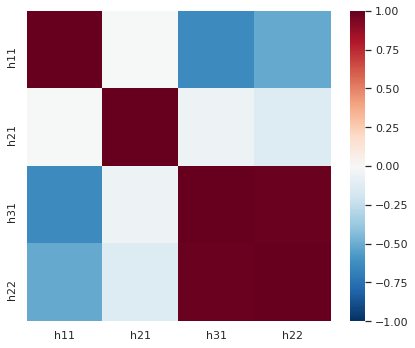

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

sns.heatmap(corr['train_labels'], vmin=-1.0, vmax=1.0, cmap='RdBu_r', center=0.0, ax=ax)

fig.tight_layout()
fig.savefig('./img/corr_train_labels.pdf')
plt.show()
plt.close(fig)

The plot shows a strong linear dependence of $h^{3,1}$ and $h^{2,2}$, and a smaller anti-linear dependence between $h^{1,1}$ and $h^{3,1}$.
In turn this can be exploited for the predictions.

We compute the difference to test the hypothesis:

In [23]:
corr_diff = np.abs(corr['train_labels'] - corr['test_labels'])

print(f'Maximal difference: {corr_diff.max().max():.3f}')

Maximal difference: 0.001


The maximal difference occurs for the following couples of labels:

In [24]:
corr_diff.idxmax()

h11    h31
h21    h11
h31    h11
h22    h11
dtype: object

The covariance matrix can be used to test a different hypothesis.
We look for its eigenvalues and test whether the matrix contains relevant information or if it needs to be transformed.

In [25]:
# limiting distribution
def marcenko_pastur(x, c):
    
    N = 2.0 * np.pi * c * x
    a = np.square(1 - np.sqrt(c))
    b = np.square(1 + np.sqrt(c))
    
    if a <= x <= b:
        return np.sqrt((b - x) * (x - a)) / N
    else:
        return 0.0

marcenko_pastur_vec = np.vectorize(marcenko_pastur)

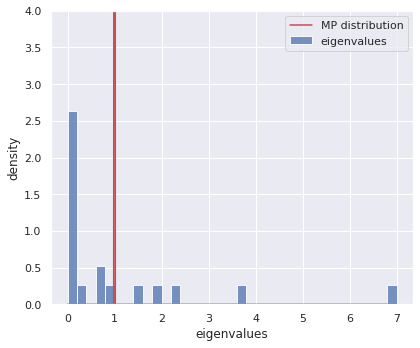

In [38]:
# compute eigenvalues and the ration between features and number of samples
eig = np.linalg.svd(cov['train_features'].values, compute_uv=False)
c   = train.shape[1] / train.shape[0]

# plot the density of the eigenvalues
fig, ax = plt.subplots(1, 1, figsize=(6,5))

sns.histplot(eig, stat='density', binwidth=0.2, color='b', label='eigenvalues', ax=ax)
sns.lineplot(x=np.linspace(0, 7, num=1000), y=marcenko_pastur_vec(np.linspace(0, 7, num=1000), c), color='r', label='MP distribution', ax=ax)

ax.set(ylim=(0.0, 4.0), xlabel='eigenvalues', ylabel='density')

fig.tight_layout()
fig.savefig('./img/cov_mp_distribution.pdf')
plt.show()
plt.close(fig)

Unfortunately, the low amount of variables considered does not enable a correct analysis using random matrix theory, which requires a data matrix $X \in \mathbb{R}^{n \times p}$ such that $n, p \to \infty$ and $\frac{p}{n} \to c$.
However, it seems that there may be principal components recovering a pattern.